In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Reference\Downloads\sales_data (1).csv")

# Convert Date column properly
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check basic info
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[ns]
 1   Product      100 non-null    object        
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    object        
 5   Region       100 non-null    object        
 6   Total_Sales  100 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 5.6+ KB
None
        Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0 2024-01-01       Phone         7  37300     CUST001   East       261100
1 2024-01-02  Headphones         4  15406     CUST002  North        61624
2 2024-01-03       Phone         2  21746     CUST003   West        43492
3 2024-01-04  Headphones         1  30895     CUST004   East        30895
4 2024-01-05

In [4]:
print("Mean Sales:", df["Total_Sales"].mean())
print("Median Sales:", df["Total_Sales"].median())
print("Mode Sales:", df["Total_Sales"].mode()[0])
print("Standard Deviation:", df["Total_Sales"].std())
print("Variance:", df["Total_Sales"].var())

Mean Sales: 123650.48
Median Sales: 97955.5
Mode Sales: 6540
Standard Deviation: 100161.08527499213
Variance: 10032243003.464245


In [5]:
print("Average Quantity:", df["Quantity"].mean())

Average Quantity: 4.78


In [6]:
print("Average Price:", df["Price"].mean())

Average Price: 25808.51


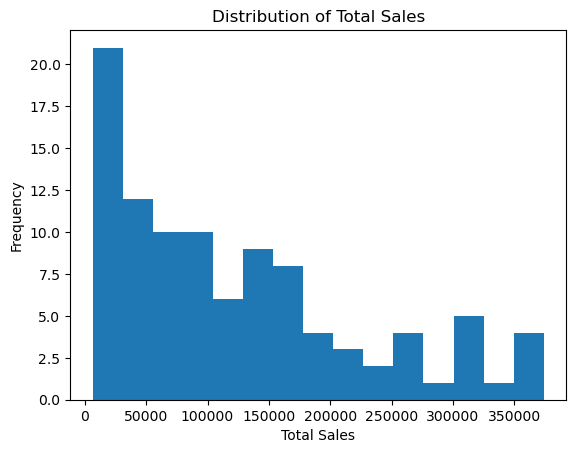

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["Total_Sales"], bins=15)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

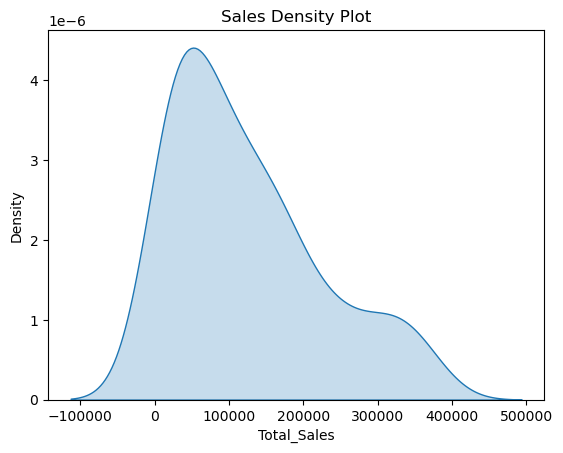

In [11]:
import seaborn as sns

sns.kdeplot(df["Total_Sales"], fill=True)
plt.title("Sales Density Plot")
plt.show()

In [9]:
correlation_matrix = df[["Quantity", "Price", "Total_Sales"]].corr()
print(correlation_matrix)

             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


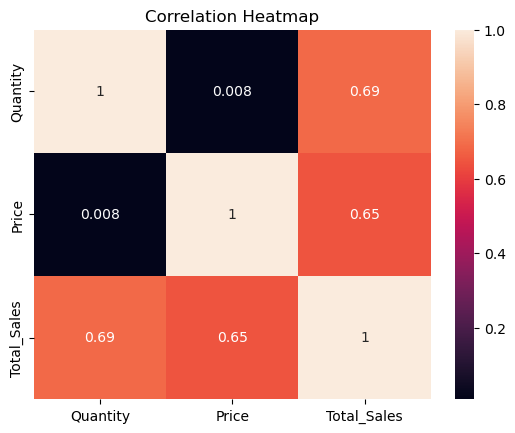

In [10]:
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
from scipy.stats import ttest_1samp
stat, p = ttest_1samp(df["Total_Sales"], 100000)
print("P-value:", p)

P-value: 0.020172184232462628


In [13]:
from scipy.stats import ttest_ind
north = df[df["Region"]=="North"]["Total_Sales"]
south = df[df["Region"]=="South"]["Total_Sales"]
stat, p = ttest_ind(north, south)
print("Region Comparison P-value:", p)

Region Comparison P-value: 0.8967974805172008


In [14]:
from scipy.stats import f_oneway

groups = [group["Total_Sales"].values for name, group in df.groupby("Region")]

stat, p = f_oneway(*groups)

print("ANOVA P-value:", p)

ANOVA P-value: 0.09723678084980039


In [15]:
import scipy.stats as stats

mean = df["Total_Sales"].mean()
sem = stats.sem(df["Total_Sales"])

ci = stats.t.interval(0.95, len(df)-1, loc=mean, scale=sem)

print("95% Confidence Interval:", ci)

margin_error = ci[1] - mean
print("Margin of Error:", margin_error)

95% Confidence Interval: (np.float64(103776.34767158539), np.float64(143524.6123284146))
Margin of Error: 19874.132328414606


In [16]:
from sklearn.linear_model import LinearRegression

X = df[["Quantity", "Price"]]
y = df["Total_Sales"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R-Squared:", model.score(X, y))

Intercept: -121682.21737545486
Coefficients: [2.64308402e+04 4.61062190e+00]
R-Squared: 0.8839073148081258
